In [1]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.4 MB/s eta 0:00:00


In [2]:
import cv2
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving videoclip5.mp4 to videoclip5.mp4
Saving videoclip4.mp4 to videoclip4.mp4
Saving videoclip3.mp4 to videoclip3.mp4
Saving videoclip2.mp4 to videoclip2.mp4
Saving videoclip1.mp4 to videoclip1.mp4


In [4]:
video_path = list(uploaded.keys())[0]
output_folder = "frames"
os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)
count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(f"{output_folder}/frame_{count}.jpg", frame)
    count += 1

cap.release()
print("Frames extracted:", count)

Frames extracted: 263


In [5]:
!zip -r frames.zip frames

  adding: frames/ (stored 0%)
  adding: frames/frame_138.jpg (deflated 3%)
  adding: frames/frame_83.jpg (deflated 2%)
  adding: frames/frame_157.jpg (deflated 3%)
  adding: frames/frame_223.jpg (deflated 1%)
  adding: frames/frame_31.jpg (deflated 4%)
  adding: frames/frame_135.jpg (deflated 3%)
  adding: frames/frame_14.jpg (deflated 3%)
  adding: frames/frame_126.jpg (deflated 4%)
  adding: frames/frame_10.jpg (deflated 2%)
  adding: frames/frame_208.jpg (deflated 1%)
  adding: frames/frame_73.jpg (deflated 2%)
  adding: frames/frame_146.jpg (deflated 3%)
  adding: frames/frame_142.jpg (deflated 2%)
  adding: frames/frame_256.jpg (deflated 2%)
  adding: frames/frame_251.jpg (deflated 2%)
  adding: frames/frame_65.jpg (deflated 2%)
  adding: frames/frame_210.jpg (deflated 2%)
  adding: frames/frame_62.jpg (deflated 2%)
  adding: frames/frame_184.jpg (deflated 2%)
  adding: frames/frame_246.jpg (deflated 1%)
  adding: frames/frame_36.jpg (deflated 4%)
  adding: frames/frame_17.jpg (de

In [6]:
files.download("frames.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
uploaded = files.upload()

Saving frames.zip to frames (1).zip


In [9]:
print(uploaded.keys())

dict_keys(['frames (1).zip'])


In [10]:
import zipfile

with zipfile.ZipFile("frames (1).zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [12]:
with open("dataset.yaml", "w") as f:
    f.write("""
train: dataset/images/train
val: dataset/images/val

nc: 1
names: ["player"]
""")

In [14]:
!ls dataset

frames


In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model("dataset/frames", save=True, show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/263 /content/dataset/frames/frame_0.jpg: 640x352 5 persons, 347.2ms
image 2/263 /content/dataset/frames/frame_1.jpg: 640x352 5 persons, 159.6ms
image 3/263 /content/dataset/frames/frame_10.jpg: 640x352 3 persons, 158.0ms
image 4/263 /content/dataset/frames/frame_100.jpg: 640x352 4 persons, 138.3ms
image 5/263 /content/dataset/frames/frame_101.jpg: 640x352 5 persons, 1 baseball glove, 143.2ms
image 6/263 /content/dataset/frames/frame_102.jpg: 640x352 5 persons, 1 baseball glove, 142.9ms
image 7/263 /content/dataset/frames/frame_103.jpg: 640x352 4 persons, 138.7ms
image 8/263 /content/dataset/frames/frame_104.jpg: 640x352 4 persons, 164.2ms
image 9/263 /content/dataset/frames/frame_105.jpg: 640x352 5 persons, 149.2ms
image 10/263 /content/dataset/frames/frame_106.jpg: 640x352 5 persons, 144.7ms
image 11/263 /content/dataset/frames/frame_107.jpg: 640x352 7 persons, 146.2ms
image 12/263 /content/dataset/fram

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [3]:
model("dataset/frames", save=True, show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/263 /content/dataset/frames/frame_0.jpg: 640x352 5 persons, 201.2ms
image 2/263 /content/dataset/frames/frame_1.jpg: 640x352 5 persons, 163.2ms
image 3/263 /content/dataset/frames/frame_10.jpg: 640x352 3 persons, 144.6ms
image 4/263 /content/dataset/frames/frame_100.jpg: 640x352 4 persons, 136.8ms
image 5/263 /content/dataset/frames/frame_101.jpg: 640x352 5 persons, 1 baseball glove, 156.3ms
image 6/263 /content/dataset/frames/frame_102.jpg: 640x352 5 persons, 1 baseball glove, 146.5ms
image 7/263 /content/dataset/frames/frame_103.jpg: 640x352 4 persons, 151.2ms
image 8/263 /content/dataset/frames/frame_104.jpg: 640x352 4 persons, 143.7ms
image 9/263 /content/dataset/frames/frame_105.jpg: 640x352 5 persons, 153.0ms
image 10/263 /content/dataset/frames/frame_106.jpg: 640x352 5 persons, 148.0ms
image 11/263 /content/dataset/frames/frame_107.jpg: 640x352 7 persons, 156.4ms
image 12/263 /content/dataset/fram

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [4]:
!ls runs/detect/predict

frame_0.jpg    frame_148.jpg  frame_196.jpg  frame_243.jpg  frame_54.jpg
frame_100.jpg  frame_149.jpg  frame_197.jpg  frame_244.jpg  frame_55.jpg
frame_101.jpg  frame_14.jpg   frame_198.jpg  frame_245.jpg  frame_56.jpg
frame_102.jpg  frame_150.jpg  frame_199.jpg  frame_246.jpg  frame_57.jpg
frame_103.jpg  frame_151.jpg  frame_19.jpg   frame_247.jpg  frame_58.jpg
frame_104.jpg  frame_152.jpg  frame_1.jpg    frame_248.jpg  frame_59.jpg
frame_105.jpg  frame_153.jpg  frame_200.jpg  frame_249.jpg  frame_5.jpg
frame_106.jpg  frame_154.jpg  frame_201.jpg  frame_24.jpg   frame_60.jpg
frame_107.jpg  frame_155.jpg  frame_202.jpg  frame_250.jpg  frame_61.jpg
frame_108.jpg  frame_156.jpg  frame_203.jpg  frame_251.jpg  frame_62.jpg
frame_109.jpg  frame_157.jpg  frame_204.jpg  frame_252.jpg  frame_63.jpg
frame_10.jpg   frame_158.jpg  frame_205.jpg  frame_253.jpg  frame_64.jpg
frame_110.jpg  frame_159.jpg  frame_206.jpg  frame_254.jpg  frame_65.jpg
frame_111.jpg  frame_15.jpg   frame_207.jpg  frame_2

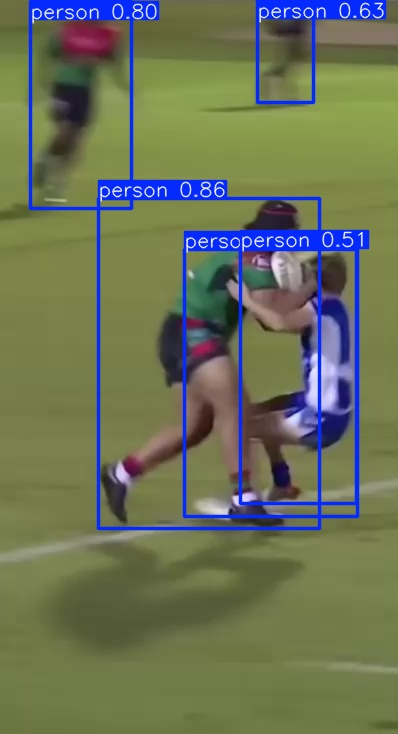

In [5]:
from IPython.display import Image, display

display(Image(filename='runs/detect/predict/frame_0.jpg'))

In [6]:
from google.colab import files
files.upload()

Saving videotesting.mp4 to videotesting.mp4


{'videotesting.mp4': b'\x00\x00\x00\x18ftypmp42\x00\x00\x00\x00mp41isom\x00\x00\x00(uuid\\\xa7\x08\xfb2\x8eB\x05\xa8ae\x0e\xca\n\x95\x96\x00\x00\x00\x0c10.0.26200.0\x00\x0c\x1c(mdat\x00\x00\x00\x00\x00\x00\x00\x10\x00\x00\x00\x02\t\x10\x00\x003\xaee\x88\x84\x01\x7f\xea\x07\xeaS\xf3B\xbf\x90`\xd4\xddy"\x96\xddC\xb9K\xa79Hn\xea%\xb7[2\xb6\xed\xe25\xbe\xe3|\x81:M\xe8\x08\xf7\xcfJ\x02\x9254qo\x19\xc3\xb2W\x12\x93{7\xc0\x0ci>pK\xa8\xeej\xa8\x15J-\xad\x0f\xf9j\xd6\xa4\x03\xaf\xb8\xd1\x1c\x13opz\x14\xf5K\x8c\x8b\x19\x8a\xf4\\2N\xe8b"\xd7\xb7\x9f\xe1\x943\xd7-;\xc5\nI|\x0c\xacN53\xa5\xb8\xf4\x9f\x03\x1a\xf9\x9a\xa4\x1c\xc2b\xf2\xd1\x1b\xc6\x7f-\xa4\x9bZ\xadJ\x0b\xfdIO\x94\xf0f\xda\xe89\xe1\x9d\xf6|\x81\xc6\xcfM\xda\xe9\xb3\xe4f9;:\x80\x042\xd3^\xe1\xa1\x9c9\x10\xc0\xfb\xce\xca\xedvc\xcb\x8e\xb2\xb7\x18\xe9?*\x8a\xd2\x80\xea\xd4\x89\x9f\xe7\x18t\x11\xf006\xe08\x19L\x9c\x96\r"\xf3D\xedJ\xf12\xee\xdc~nm\xc4\xec\'\x90\xc8\xbdU\x10\x86\x98\x03\xa5\x95\x1c\xed)Qy]\xfe%{!\xf1\xa94\xd5H\x86\xea\xe2j:\

In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.track(source="videotesting.mp4", show=True, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/120) /content/videotesting.mp4: 640x352 2 persons, 163.9ms
video 1/1 (frame 2/120) /content/videotesting.mp4: 640x352 2 persons, 174.1ms
video 1/1 (frame 3/120) /content/videotesting.mp4: 640x352 1 person, 159.3ms
video 1/1 (frame 4/120) /content/videotesting.mp4: 640x352 1 person, 151.3ms
video 1/1 (frame 5/120) /content/videotesting.mp4: 640x352 1 person, 146.0ms
video 1/1 (frame 6/120) /content/videotesting.mp4: 640x352 1 person, 15

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [9]:
pose_model = YOLO("yolov8n-pose.pt")

pose_model("videotesting.mp4", show=True, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/120) /content/videotesting.mp4: 640x352 1 person, 248.2ms
video 1/1 (frame 2/120) /content/videotesting.mp4: 640x352 1 person, 229.1ms
video 1/1 (frame 3/120) /content/videotesting.mp4: 640x352 1 person, 235.3ms
video 1/1 (frame 4/120) /content/videotesting.mp4: 640x352 1 person, 244.2ms
video 1/1 (frame 5/120) /content/videotesting.mp4: 640x352 1 person, 270.1ms
video 1/1 (frame 6/120) /content/videotesting.mp4: 640x352 1 person, 237.

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: ultralytics.engine.results.Keypoints object
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[ 19,  16,  17],
         [ 19,  16,  17],
         [ 19,  16,  17],
         ...,
         [ 20,  15,  16],
         [ 20,  15,  16],
         [ 20,  15,  16]],
 
        [[ 19,  16,  17],
         [ 19,  16,  17],
         [ 19,  16,  17],
         ...,
         [ 20,  15,  16],
         [ 20,  15,  16],
         [ 20,  15,  16]],
 
        [[ 18,  15,  16],
         [ 18,  15,  16],
         [ 18,  15,  16],
         ...,
         [ 19,  14,  15],
         [ 19,  14,  15],
         [ 19,  14,  15]],
 
        ...,
 
        [[ 49, 136, 100],
         [ 49, 136, 100],
         [ 49, 136, 100],
         ...,
         [ 49, 134,  98],
         [ 49, 134,  98],
         [ 49, 134,  98]],
 
        [[ 49, 136, 100],
         [ 49, 136, 100],
         [ 49, 136,

In [11]:
!zip -r outputs.zip runs
from google.colab import files
files.download("outputs.zip")

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/track/ (stored 0%)
  adding: runs/detect/track/videotesting.avi (deflated 2%)
  adding: runs/detect/predict2/ (stored 0%)
  adding: runs/detect/predict2/frame_138.jpg (deflated 3%)
  adding: runs/detect/predict2/frame_83.jpg (deflated 2%)
  adding: runs/detect/predict2/frame_157.jpg (deflated 3%)
  adding: runs/detect/predict2/frame_223.jpg (deflated 2%)
  adding: runs/detect/predict2/frame_31.jpg (deflated 5%)
  adding: runs/detect/predict2/frame_135.jpg (deflated 3%)
  adding: runs/detect/predict2/frame_14.jpg (deflated 2%)
  adding: runs/detect/predict2/frame_126.jpg (deflated 3%)
  adding: runs/detect/predict2/frame_10.jpg (deflated 2%)
  adding: runs/detect/predict2/frame_208.jpg (deflated 2%)
  adding: runs/detect/predict2/frame_73.jpg (deflated 3%)
  adding: runs/detect/predict2/frame_146.jpg (deflated 3%)
  adding: runs/detect/predict2/frame_142.jpg (deflated 3%)
  adding: runs/detect/predict2/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>